# Chemical-space QSAR with Morgan fingerprints

All model inputs below use radius-2 Morgan fingerprints with 2,048 bits.

ChEMBL_Activity.csv
        │
        ▼
load_chembl_csv()
        │
        ▼
prepare_endpoint()
        │
        │  Keep:
        │  IC50
        │  relation "="
        │  units nM
        │  valid pChEMBL
        │  valid SMILES
        ▼
standardize_dataframe()
        │
        │  df["Smiles"].apply(standardize_smiles)
        │
        ▼
SMILES_STD
        │
        ▼
aggregate_replicates()
        │
        │  groupby standardized molecule
        │  median pChEMBL
        │  count replicates
        │  measure disagreement
        ▼
add_scaffolds()
        │
        │  df["SMILES_STD"].apply(calculate_scaffold)
        │
        ├────────────► scaffold QC
        │              top scaffolds
        │              molecule images
        ▼
add_morgan_fingerprints()
        │
        │  df["SMILES_STD"].apply(calculate_morgan_fingerprint)
        │
        ▼
2,048-bit Morgan fingerprints (radius 2)
        │
        ▼
scaffold_train_test_split()
        │
        ├──── train scaffolds
        │
        └──── completely unseen test scaffolds
                 │
                 ▼
prepare_fingerprint_features()
        │
        │ fixed 2,048-bit feature space
        ▼
Morgan fingerprint bits
        │
        ├───────────────┐
        ▼               ▼
run_random_search()   run_bayesian_search()
        │               │
        │ RandomizedCV  │ BayesSearchCV
        │               │
        └───────┬───────┘
                ▼
        choose_best_search()
                │
                ▼
      best scaffold-CV RMSE
                │
                ▼
         evaluate_model()
                │
                ▼
        untouched test set
                │
        ┌───────┼────────┐
        ▼       ▼        ▼
       RMSE     MAE       R²

In [ ]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import loguniform

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.impute import SimpleImputer
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from skopt import BayesSearchCV
from skopt.space import Real

RANDOM_STATE = 42
UNCHARGER = rdMolStandardize.Uncharger()

MORGAN_RADIUS = 2
MORGAN_N_BITS = 2048
MORGAN_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_N_BITS,
)

In [ ]:
dataset_path = "/home/pospim/Desktop/school/bip_chem/exer/ChEMBL_Activity.csv"
dataset = pd.read_csv(dataset_path, delimiter=";")
dataset.head
dataset.columns

/tmp/ipykernel_342327/1515981327.py:2: DtypeWarning: Columns (0: Assay Tissue ChEMBL ID, 1: Assay Tissue Name, 2: Assay Subcellular Fraction, 3: Assay Variant Accession, 4: Assay Variant Mutation) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv(dataset_path, delimiter=";")


Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

## Assay effect on measured pChEMBL

The plot uses the same exact-relation IC50/nM endpoint as the modeling dataset. Each point is predicted from the mean of the *other* measurements in its assay. Singleton assays fall back to the global mean, preventing the inflated fit obtained by predicting a row with a mean that contains that same row.

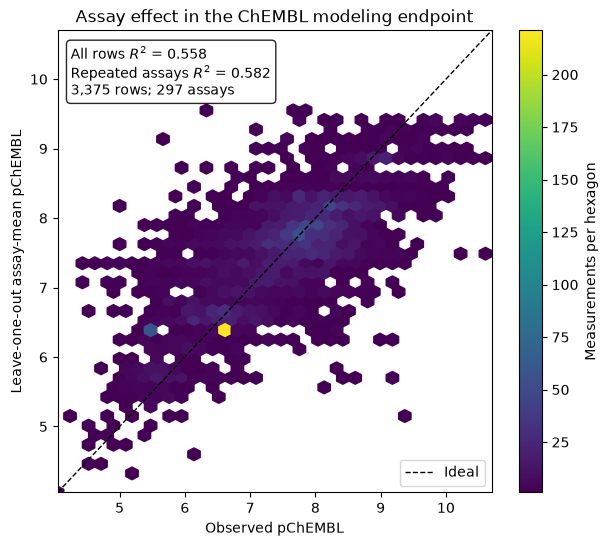

,metric,leave_one_out_assay_R2
0,All rows,0.558400
1,Repeated assays only,0.581922


In [ ]:
assay_r2_data = dataset.copy()
assay_r2_data["relation_clean"] = (
    assay_r2_data["Standard Relation"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)
assay_r2_data["pChEMBL"] = pd.to_numeric(
    assay_r2_data["pChEMBL Value"], errors="coerce"
)
assay_r2_data = assay_r2_data.loc[
    assay_r2_data["Standard Type"].eq("IC50")
    & assay_r2_data["relation_clean"].eq("=")
    & assay_r2_data["Standard Units"].eq("nM")
    & assay_r2_data["pChEMBL"].notna()
    & assay_r2_data["Smiles"].fillna("").astype(str).str.strip().ne("")
    & assay_r2_data["Assay ChEMBL ID"].notna()
].copy()

assay_groups = assay_r2_data.groupby("Assay ChEMBL ID")["pChEMBL"]
assay_sums = assay_r2_data["Assay ChEMBL ID"].map(assay_groups.sum()).to_numpy(float)
assay_counts = assay_r2_data["Assay ChEMBL ID"].map(assay_groups.size()).to_numpy(int)
observed = assay_r2_data["pChEMBL"].to_numpy(float)
assay_loo_prediction = np.full(len(assay_r2_data), observed.mean(), dtype=float)
repeated = assay_counts > 1
assay_loo_prediction[repeated] = (
    assay_sums[repeated] - observed[repeated]
) / (assay_counts[repeated] - 1)

assay_r2 = r2_score(observed, assay_loo_prediction)
repeated_assay_r2 = r2_score(
    observed[repeated], assay_loo_prediction[repeated]
)
assay_r2_data["assay_loo_predicted_pChEMBL"] = assay_loo_prediction

fig, ax = plt.subplots(figsize=(7, 6))
density = ax.hexbin(
    observed,
    assay_loo_prediction,
    gridsize=35,
    mincnt=1,
    cmap="viridis",
)
limits = [
    min(observed.min(), assay_loo_prediction.min()),
    max(observed.max(), assay_loo_prediction.max()),
]
ax.plot(limits, limits, "--", color="black", linewidth=1, label="Ideal")
ax.set(
    xlim=limits,
    ylim=limits,
    xlabel="Observed pChEMBL",
    ylabel="Leave-one-out assay-mean pChEMBL",
    title="Assay effect in the ChEMBL modeling endpoint",
)
ax.text(
    0.03,
    0.97,
    f"All rows $R^2$ = {assay_r2:.3f}\n"
    f"Repeated assays $R^2$ = {repeated_assay_r2:.3f}\n"
    f"{len(assay_r2_data):,} rows; {assay_r2_data['Assay ChEMBL ID'].nunique():,} assays",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)
fig.colorbar(density, ax=ax, label="Measurements per hexagon")
ax.legend(loc="lower right")
plt.show()

display(
    pd.DataFrame({
        "metric": ["All rows", "Repeated assays only"],
        "leave_one_out_assay_R2": [assay_r2, repeated_assay_r2],
    })
)

In [ ]:
def prepare_data(df):
    data = df.copy()

    data["relation_clean"] = (
        data["Standard Relation"]
        .astype(str)
        .str.replace("'", "", regex=False)
        .str.strip()
    )
    data["pChEMBL"] = pd.to_numeric(
        data["pChEMBL Value"],
        errors="coerce"
    )

    mask = (
        (data["Standard Type"] == "IC50")
        & (data["relation_clean"] == "=")
        & (data["Standard Units"] == "nM")
        & (data["pChEMBL"].notna())
        & (data["Smiles"].str.strip() != "")
    )

    return data.loc[mask].copy()

clean_data = prepare_data(dataset)
clean_data.head

<bound method NDFrame.head of       Molecule ChEMBL ID  Molecule Name  Molecule Max Phase  Molecular Weight  \
2          CHEMBL1276308   MIFEPRISTONE                 4.0            429.60   
3              CHEMBL131   PREDNISOLONE                 4.0            360.45   
4          CHEMBL4202668            NaN                 NaN            506.55   
5          CHEMBL4211898            NaN                 NaN            528.99   
8          CHEMBL4217184            NaN                 NaN            485.26   
...                  ...            ...                 ...               ...   
17886      CHEMBL1201396    FLUTICASONE                 3.0            444.52   
17924       CHEMBL384467  DEXAMETHASONE                 4.0            392.47   
17925      CHEMBL5812828            NaN                 NaN            608.64   
17926      CHEMBL6031431            NaN                 NaN            684.77   
17927      CHEMBL5758568            NaN                 NaN            754.90  

In [ ]:
def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)

        if not mol:
            return pd.Series({
                "SMILES_STD": np.nan,
                "standardization_changed": False,
                "standardization_error": "Could not parse SMILES",
            })
        mol = rdMolStandardize.Cleanup(mol)

        mol = rdMolStandardize.FragmentParent(mol)

        # Keep this cell self-contained when it is rerun out of order.
        uncharger = globals().get("UNCHARGER")
        if uncharger is None:
            uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)

        Chem.SanitizeMol(mol)

        standardized = Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True
        )
        return pd.Series({
            "SMILES_STD": standardized,
            "standardization_changed":
                standardized != smiles,
            "standardization_error": "",
        })

    except Exception as exc:

        return pd.Series({
            "SMILES_STD": np.nan,
            "standardization_changed": False,
            "standardization_error": str(exc),
        })

standardization = (
    clean_data["Smiles"]
    .apply(standardize_smiles)
)

[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Normalizer
[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Normalizer
[10:14:20] Running LargestFragmentChooser
[10:14:20] Running Uncharger
[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Normalizer
[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Normalizer
[10:14:20] Running LargestFragmentChooser
[10:14:20] Running Uncharger
[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Normalizer
[10:14:20] Initializing MetalDisconnector
[10:14:20] Running MetalDisconnector
[10:14:20] Initializing Normalizer
[10:14:20] Running Norma

In [ ]:
standardized = pd.concat(
    [
        clean_data.reset_index(drop=True),
        standardization.reset_index(drop=True),
    ],
    axis=1,
)
standardized.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,relation_clean,pChEMBL,SMILES_STD,standardization_changed,standardization_error
0,CHEMBL1276308,MIFEPRISTONE,4.0,429.60,1.0,5.41,5,CC#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[...,IC50,'=',...,NaN,NaN,NaN,NaN,8.7,=,8.06,CC#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[...,False,
1,CHEMBL131,PREDNISOLONE,4.0,360.45,0.0,1.56,Prednisolone,C[C@]12C=CC(=O)C=C1CC[C@@H]1[C@@H]2[C@@H](O)C[...,IC50,'=',...,NaN,NaN,NaN,NaN,7.0,=,8.15,C[C@]12C=CC(=O)C=C1CC[C@@H]1[C@@H]2[C@@H](O)C[...,False,
2,CHEMBL4202668,NaN,NaN,506.55,1.0,4.88,24,C[C@H](NC(=O)C(C)(F)F)[C@H](Oc1ccc2c(cnn2-c2cc...,IC50,'=',...,NaN,NaN,NaN,NaN,4.4,=,8.36,C[C@H](NC(=O)C(C)(F)F)[C@H](Oc1ccc2c(cnn2-c2cc...,False,
3,CHEMBL4211898,NaN,NaN,528.99,2.0,5.29,27,CC(C)[C@H](NC(=O)C(C)(F)F)[C@H](Oc1ccc2c(cnn2-...,IC50,'=',...,NaN,NaN,NaN,NaN,2.6,=,8.59,CC(C)[C@H](NC(=O)C(C)(F)F)[C@H](Oc1ccc2c(cnn2-...,False,
4,CHEMBL4217184,NaN,NaN,485.26,0.0,3.15,38,N#Cc1ccc(O[C@H](c2cnc(C3CC3)nc2)[C@H](CO)NC(=O...,IC50,'=',...,NaN,NaN,NaN,NaN,42.0,=,7.38,N#Cc1ccc(O[C@H](c2cnc(C3CC3)nc2)[C@H](CO)NC(=O...,False,


In [ ]:
def aggregate_replicates(df):

    curated = (
        df.groupby(
            "SMILES_STD",
            as_index=False,
        )
        .agg(
            pChEMBL=("pChEMBL", "median"),

            pChEMBL_mean=(
                "pChEMBL",
                "mean",
            ),

            pChEMBL_min=(
                "pChEMBL",
                "min",
            ),

            pChEMBL_max=(
                "pChEMBL",
                "max",
            ),

            n_measurements=(
                "pChEMBL",
                "size",
            ),
        )
    )

    curated["pChEMBL_range"] = (
        curated["pChEMBL_max"]
        - curated["pChEMBL_min"]
    )

    return curated

curated = aggregate_replicates(standardized)

In [ ]:
def calculate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    scaffold = (
        MurckoScaffold.MurckoScaffoldSmiles(
            mol=mol,
            includeChirality=False
        )
    )
    if scaffold:
        return scaffold

    return "<ACYCLIC>"

curated["scaffold"] = (
    curated["SMILES_STD"]
    .apply(calculate_scaffold)
)

In [ ]:
def calculate_morgan_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.full(MORGAN_N_BITS, np.nan, dtype=float)
    return MORGAN_GENERATOR.GetFingerprintAsNumPy(mol).astype(np.uint8)

fingerprint_columns = [f"Morgan_{bit:04d}" for bit in range(MORGAN_N_BITS)]
if curated.empty:
    fingerprint_matrix = np.empty((0, MORGAN_N_BITS), dtype=np.uint8)
else:
    fingerprint_matrix = np.vstack(
        curated["SMILES_STD"].apply(calculate_morgan_fingerprint).to_numpy()
    )
fingerprint_df = pd.DataFrame(
    fingerprint_matrix,
    index=curated.index,
    columns=fingerprint_columns,
)
print(f"Morgan fingerprint dataset: {fingerprint_df.shape[0]:,} molecules × {fingerprint_df.shape[1]:,} bits")

Morgan fingerprint dataset: 2,129 molecules × 2,048 bits


In [ ]:
TEST_SIZE = 0.25

def scaffold_train_test_split(
        df, feature_columns, tst_size=TEST_SIZE
):
    if df.empty:
        raise ValueError(
            "No molecules are available for scaffold splitting. "
            "Rerun the standardization and aggregation cells first."
        )

    X = df[feature_columns].copy()
    y = df["pChEMBL"].to_numpy(dtype=float)
    groups = df["scaffold"].to_numpy()
    if pd.isna(groups).any():
        raise ValueError("Scaffold labels contain missing values.")
    if len(np.unique(groups)) < 2:
        raise ValueError("Scaffold splitting requires at least two distinct scaffolds.")

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=tst_size,
        random_state=RANDOM_STATE
    )

    train_idx, test_idx = next(
        splitter.split(
            X,y,groups=groups
        )
    )
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y[train_idx]
    y_test = y[test_idx]

    groups_train = groups[train_idx]
    groups_test = groups[test_idx]

    assert set(groups_train).isdisjoint(set(groups_test))

    print("\n=== OUTER SCAFFOLD SPLIT ===")
    print(f"Train molecules:  {len(train_idx):,}")
    print(f"Test molecules:   {len(test_idx):,}")
    print(f"Train scaffolds:  {len(set(groups_train)):,}")
    print(f"Test scaffolds:   {len(set(groups_test)):,}")

    return (
        X_train,
        X_test,
        y_train,
        y_test,
        groups_train,
        groups_test,
        train_idx,
        test_idx,
    )

In [ ]:
chembl_fingerprint_dataset = pd.concat(
    [
        curated.reset_index(drop=True),
        fingerprint_df.reset_index(drop=True)
    ],
    axis=1
)
model_table = chembl_fingerprint_dataset
(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    groups_train,
    groups_test,
    train_idx,
    test_idx,
) = scaffold_train_test_split(
    model_table,
    fingerprint_columns,
)


=== OUTER SCAFFOLD SPLIT ===
Train molecules:  1,616
Test molecules:   513
Train scaffolds:  518
Test scaffolds:   173


## Train and select the best scaffold-aware model

The reusable training and model-selection implementation is in `qsar_model_pipeline.py`. Both searches use the 2,048 Morgan bits and grouped cross-validation, so a scaffold never appears in both sides of a CV fold.

In [ ]:
from qsar_model_pipeline import save_selected_model, train_and_select_best_model

training_result = train_and_select_best_model(
    X_train_raw,
    y_train,
    groups_train,
    random_state=RANDOM_STATE,
    n_iter=40,
    n_splits=5,
    n_jobs=-1,
)
display(training_result.leaderboard)

model_path = save_selected_model(
    training_result,
    Path("artifacts/best_scaffold_qsar_morgan2048.joblib"),
    metadata={
        "target": "pChEMBL",
        "split": "scaffold",
        "representation": "Morgan radius=2, 2048 bits",
        "random_state": RANDOM_STATE,
    },
)
print(f"Selected {training_result.best_name}; saved fitted pipeline to {model_path}")

,model,scaffold_cv_rmse,best_parameters
0,BayesSearchCV,0.739574,"{'model__alpha': 0.008516191417826741, 'model_..."
1,RandomizedSearchCV,0.744723,"{'model__alpha': 0.06713854967599221, 'model__..."


Selected BayesSearchCV; saved fitted pipeline to artifacts/best_scaffold_qsar_morgan2048.joblib


## Results on the held-out ChEMBL scaffold test set

This comparison is performed once on the untouched outer test set. Model selection above uses only the training set and grouped cross-validation.

,model,selected,scaffold_cv_rmse,test_rmse,test_mae,test_r2
0,BayesSearchCV,True,0.739574,0.814521,0.59565,0.483775
1,RandomizedSearchCV,False,0.744723,0.815134,0.59858,0.482998


,SMILES_STD,scaffold,pChEMBL,predicted_RandomizedSearchCV,predicted_BayesSearchCV
0,C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@...,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,6.830,7.321623,7.313314
1,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4...,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,6.360,6.791249,6.775591
2,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C...,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,6.680,6.617241,6.559918
3,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,C1=C2CCC3C4CCCC4CCC3C2Cc2cnoc21,5.370,6.670096,6.737457
4,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[...,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,6.190,6.691781,6.716198
5,C#Cc1ccc(CN2CCC(n3nc(C)c4c(Cl)c(C(=O)Nc5ccc(C(...,O=C(Nc1ccc(C(=O)c2ccccc2)cc1)c1cnc2c(cnn2C2CCN...,5.560,6.183334,6.198763
6,C/C=C/C1=CC2=C(CO1)C(=O)[C@]1(C)OC(=O)[C@H](C(...,O=C1CC2CC3=C(COC=C3)C(=O)C2O1,4.460,6.721014,6.852993
7,C/C=C/[C@H]1OC2(CCCC3=Cc4c(cnn4-c4ccc(F)cc4)C[...,C1=C2CCCC3(OCCO3)C2Cc2cnn(-c3ccccc3)c21,8.600,7.943820,7.982913
8,C/C=C/[C@]1(O)C[C@H]2CCc3cc(O)ccc3[C@]2(CC)C[C...,c1ccc2c(c1)CCC1CCCCC21,8.450,7.870974,7.798951
9,C=C1OC(C)=N[C@]12CC[C@H]1[C@@H]3CCC4=CC(=O)CCC...,C=C1OC=NC12CCC1C3CCC4=CC(=O)CCC4=C3C(c3ccccc3)...,6.340,7.600537,7.744867


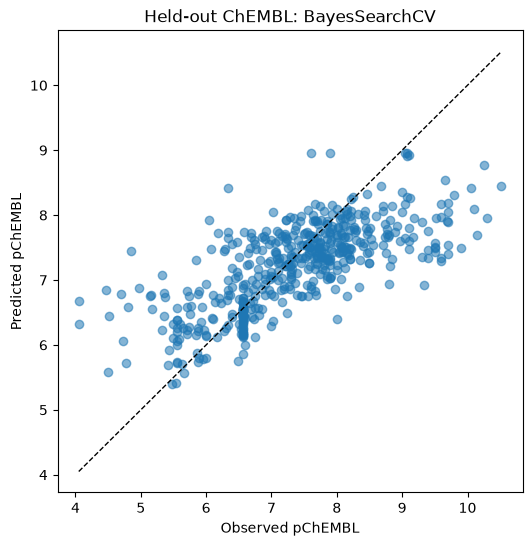

In [ ]:
chembl_test_results = []
chembl_test_predictions = model_table.iloc[test_idx][
    ["SMILES_STD", "scaffold", "pChEMBL"]
].reset_index(drop=True).copy()

for model_name, search in training_result.searches.items():
    predictions = search.best_estimator_.predict(X_test_raw)
    chembl_test_results.append({
        "model": model_name,
        "selected": model_name == training_result.best_name,
        "scaffold_cv_rmse": -float(search.best_score_),
        "test_rmse": mean_squared_error(y_test, predictions) ** 0.5,
        "test_mae": mean_absolute_error(y_test, predictions),
        "test_r2": r2_score(y_test, predictions),
    })
    chembl_test_predictions[f"predicted_{model_name}"] = predictions

chembl_test_results = (
    pd.DataFrame(chembl_test_results)
    .sort_values("scaffold_cv_rmse")
    .reset_index(drop=True)
)
display(chembl_test_results)
display(chembl_test_predictions.head(20))

best_test_predictions = training_result.best_model.predict(X_test_raw)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_test_predictions, alpha=0.55)
limits = [min(y_test.min(), best_test_predictions.min()), max(y_test.max(), best_test_predictions.max())]
ax.plot(limits, limits, "k--", linewidth=1)
ax.set(xlabel="Observed pChEMBL", ylabel="Predicted pChEMBL", title=f"Held-out ChEMBL: {training_result.best_name}")
plt.show()

## Apply the selected model to generated molecules

Prediction remains in the notebook because loading and inspecting generated chemistry is dataset-specific. Invalid SMILES are retained with a missing prediction.

In [ ]:
def predict_generated_molecules(generated_data, smiles_column=None):
    output = generated_data.copy()
    if smiles_column is None:
        candidates = {"smiles", "canonical_smiles", "smiles_std"}
        smiles_column = next(
            (column for column in output.columns if column.strip().lower() in candidates),
            None,
        )
    if smiles_column is None or smiles_column not in output.columns:
        raise ValueError("Provide the name of the generated-data SMILES column.")

    generated_standardization = output[smiles_column].apply(standardize_smiles)
    output["SMILES_STD"] = generated_standardization["SMILES_STD"]
    output["standardization_error"] = generated_standardization["standardization_error"]
    valid = output["SMILES_STD"].notna()
    output["predicted_pChEMBL"] = np.nan
    generated_fingerprint_dataset = pd.DataFrame(
        np.nan,
        index=output.index,
        columns=training_result.feature_columns,
    )

    if valid.any():
        generated_fingerprints = pd.DataFrame(
            np.vstack(
                output.loc[valid, "SMILES_STD"]
                .apply(calculate_morgan_fingerprint)
                .to_numpy()
            ),
            index=output.index[valid],
            columns=fingerprint_columns,
        ).reindex(columns=training_result.feature_columns)
        output.loc[valid, "predicted_pChEMBL"] = training_result.best_model.predict(
            generated_fingerprints
        )
        generated_fingerprint_dataset.loc[valid, :] = generated_fingerprints.to_numpy()
    return pd.concat([output, generated_fingerprint_dataset], axis=1)

GENERATED_DATA_PATH = Path("generated_data.csv")
if GENERATED_DATA_PATH.exists():
    generated_data = pd.read_csv(GENERATED_DATA_PATH)
    generated_predictions = predict_generated_molecules(generated_data)
    result_columns = [column for column in generated_data.columns if column in generated_predictions.columns]
    result_columns += ["SMILES_STD", "standardization_error", "predicted_pChEMBL"]
    display(
        generated_predictions
        .sort_values("predicted_pChEMBL", ascending=False)
        .loc[:, list(dict.fromkeys(result_columns))]
        .head(25)
    )
else:
    print(
        f"Place generated molecules in {GENERATED_DATA_PATH} or call "
        "predict_generated_molecules(your_dataframe, smiles_column='your_smiles_column')."
    )

Place generated molecules in generated_data.csv or call predict_generated_molecules(your_dataframe, smiles_column='your_smiles_column').
